# Ablation figure + table generator

Reads a wandb CSV export (one row per run, columns include `probe/FP`, `probe/MP`,
`probe/DayM`, `probe/YearMD`, plus the sweep axes `numLayers`, `numHeads`, `EPOCHS`)
and emits, for each of the three studies (`heads`, `layers`, `epochs`):

1. A grouped bar chart → `figure/{study}.png`
2. A percentage table  → `figure/{study}_table.csv` + `figure/{study}_table.md`

| File | Sweep | Held fixed |
| --- | --- | --- |
| `figure/heads.png`,  `heads_table.{csv,md}`  | numHeads ∈ {2, 3, 6, 8}         | numLayers = 4, EPOCHS = 1 |
| `figure/layers.png`, `layers_table.{csv,md}` | numLayers ∈ {2, 3, 4, 6, 8, 10} | numHeads = 3, dmodel = 192, EPOCHS = 1 |
| `figure/epochs.png`, `epochs_table.{csv,md}` | EPOCHS ∈ {1, 2, 4, 6}           | numLayers = 4, numHeads = 3, dmodel = 192 |

In [17]:
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

# Auto-detect the most recent wandb export anywhere under the notebook's dir;
# override CSV_PATH to pin a specific file.
CSV_PATH: str | None = None
if CSV_PATH is None:
    candidates = sorted(
        glob("wandb_export_*.csv")
        + glob("source-results/wandb_export_*.csv")
        + glob("../wandb_export_*.csv")
    )
    if not candidates:
        raise FileNotFoundError(
            "No wandb_export_*.csv found near this notebook. Drop the CSV in "
            "./source-results/ (or the notebook's directory) or set CSV_PATH above."
        )
    CSV_PATH = candidates[-1]
print(f"Reading {CSV_PATH}")

FIGURE_DIR = Path("figure")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


Reading source-results/wandb_export_2026-05-17T11_24_39.814-04_00.csv


In [18]:
df = pd.read_csv(CSV_PATH)

# Run names look like "heads-8-20260517-005847". Split into (study, value).
parts = df["Name"].str.split("-")
df["study"]       = parts.str[0]
df["sweep_value"] = parts.str[1].astype(int)

# Probe metrics, in probe code's natural order (easy → hard).
METRICS       = ["probe/MP", "probe/DayM", "probe/YearMD", "probe/FP"]
LABELS        = ["MP (month)", "DayM (day | M)", "YearMD (year | M,D)", "FP (full pred.)"]
SHORT_LABELS  = ["MP", "DayM", "YearMD", "FP"]
COLORS        = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

print(df.groupby("study")["Name"].count().rename("n_runs"))
df[["Name", "study", "sweep_value", *METRICS]].sort_values(["study", "sweep_value"])

study
epochs    4
heads     4
layers    6
Name: n_runs, dtype: int64


,Name,study,sweep_value,probe/MP,probe/DayM,probe/YearMD,probe/FP
13,epochs-1-20260517-005847,epochs,1,0.108261,0.769565,0.794348,0.050870
12,epochs-2-20260517-005847,epochs,2,0.813913,0.947826,0.941739,0.741739
11,epochs-4-20260517-005847,epochs,4,0.844783,0.982174,1.000000,0.830435
10,epochs-6-20260517-005847,epochs,6,0.907391,0.980000,0.978696,0.869565
3,heads-2-20260517-005847,heads,2,0.049130,0.020870,0.236957,0.000000
2,heads-3-20260517-005847,heads,3,0.073478,0.879565,0.822174,0.030435
1,heads-6-20260517-005847,heads,6,0.881304,0.998696,1.000000,0.880435
0,heads-8-20260517-005847,heads,8,0.850435,0.996087,0.999130,0.846957
9,layers-2-20260517-005847,layers,2,0.033478,0.123478,0.619130,0.003913
8,layers-3-20260517-005847,layers,3,0.070870,0.942174,0.857826,0.060870


In [19]:
AXIS_LABEL = {
    "heads":  "numHeads",
    "layers": "numLayers",
    "epochs": "EPOCHS",
}


def plot_study(study: str, x_label: str, fixed_config: str, out_name: str | None = None):
    """Grouped bar chart of MP / DayM / YearMD / FP across one sweep axis.

    Bar value labels and the y-axis ticks are both formatted as percentages
    (e.g. `85.0%`), even though the underlying probe values are fractions in
    [0, 1] — matplotlib's `PercentFormatter(xmax=1)` does the scaling.
    """
    sub = df[df["study"] == study].sort_values("sweep_value")
    if sub.empty:
        raise ValueError(
            f"No rows for study={study!r}. Found: {sorted(df['study'].unique())}"
        )

    x_vals = sub["sweep_value"].tolist()
    x      = np.arange(len(x_vals))
    bar_w  = 0.2
    offsets = (np.arange(len(METRICS)) - (len(METRICS) - 1) / 2) * bar_w

    fig_w = max(7, 1.2 * len(x_vals) + 4)
    fig, ax = plt.subplots(figsize=(fig_w, 4.8))

    for offset, metric, label, color in zip(offsets, METRICS, LABELS, COLORS):
        ys = sub[metric].values.astype(float)
        bars = ax.bar(
            x + offset, ys, bar_w,
            label=label, color=color, edgecolor="white", linewidth=0.5,
        )
        for bar, y in zip(bars, ys):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y + 0.012,
                f"{y * 100:.1f}%",
                ha="center", va="bottom", fontsize=7, color="#333",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_xlabel(x_label)
    ax.set_ylabel("Probe accuracy")
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_title(f"Ablation — {study} sweep\n({fixed_config})", fontsize=11)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.92)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    fig.tight_layout()

    out_path = FIGURE_DIR / (out_name or f"{study}.png")
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")


def build_table(study: str) -> pd.DataFrame:
    """Per-study table indexed by sweep value, columns = MP/DayM/YearMD/FP (%)."""
    sub = df[df["study"] == study].sort_values("sweep_value")
    if sub.empty:
        raise ValueError(f"No rows for study={study!r}.")
    tbl = sub.set_index("sweep_value")[METRICS]
    tbl.columns = SHORT_LABELS
    tbl.index.name = AXIS_LABEL[study]
    return (tbl.astype(float) * 100).round(1)


def df_to_markdown(d: pd.DataFrame) -> str:
    """Render a DataFrame as a GitHub-flavored markdown table with `xx.x%` cells.

    Avoids the optional `tabulate` dep that pandas' built-in `to_markdown` requires.
    """
    cols   = list(d.columns)
    header = "| " + (d.index.name or "") + " | " + " | ".join(cols) + " |"
    sep    = "|" + "|".join([" --- "] * (len(cols) + 1)) + "|"
    rows   = [
        "| " + str(i) + " | " + " | ".join(f"{d.at[i, c]:.1f}%" for c in cols) + " |"
        for i in d.index
    ]
    return "\n".join([header, sep, *rows])


def show_and_save_table(study: str) -> pd.DataFrame:
    """Print + save the percentage table for one study. Returns the styled DataFrame."""
    tbl = build_table(study)

    # Persist machine-readable CSV (raw percentages, one decimal).
    csv_path = FIGURE_DIR / f"{study}_table.csv"
    tbl.to_csv(csv_path)

    # Persist human-readable markdown.
    md_path = FIGURE_DIR / f"{study}_table.md"
    md_path.write_text(
        f"### Ablation — {study} sweep (probe accuracy %)\n\n" + df_to_markdown(tbl) + "\n"
    )
    print(f"Saved → {csv_path}")
    print(f"Saved → {md_path}")

    # Return a Styler so the rendered cell shows e.g. `85.0%`.
    return tbl.style.format("{:.1f}%").set_caption(f"{study} sweep — probe accuracy")


## Heads sweep

Holding `numLayers = 4`, `EPOCHS = 1`. `dmodel = 64 · numHeads` per the paper's ℓ-h convention.

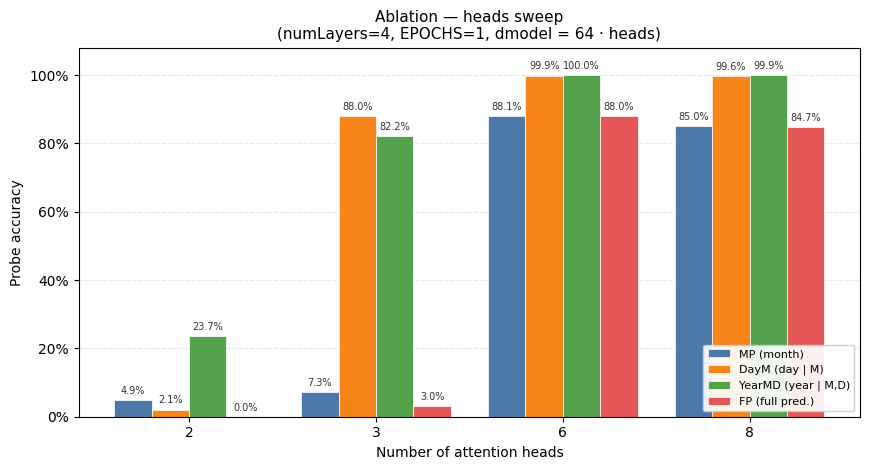

Saved → figure/heads.png


In [20]:
plot_study(
    study="heads",
    x_label="Number of attention heads",
    fixed_config="numLayers=4, EPOCHS=1, dmodel = 64 · heads",
)

In [21]:
show_and_save_table("heads")

Saved → figure/heads_table.csv
Saved → figure/heads_table.md


,MP,DayM,YearMD,FP
numHeads,,,,
2,4.9%,2.1%,23.7%,0.0%
3,7.3%,88.0%,82.2%,3.0%
6,88.1%,99.9%,100.0%,88.0%
8,85.0%,99.6%,99.9%,84.7%


## Layers sweep

Holding `numHeads = 3` (so `dmodel = 192`) and `EPOCHS = 1`.

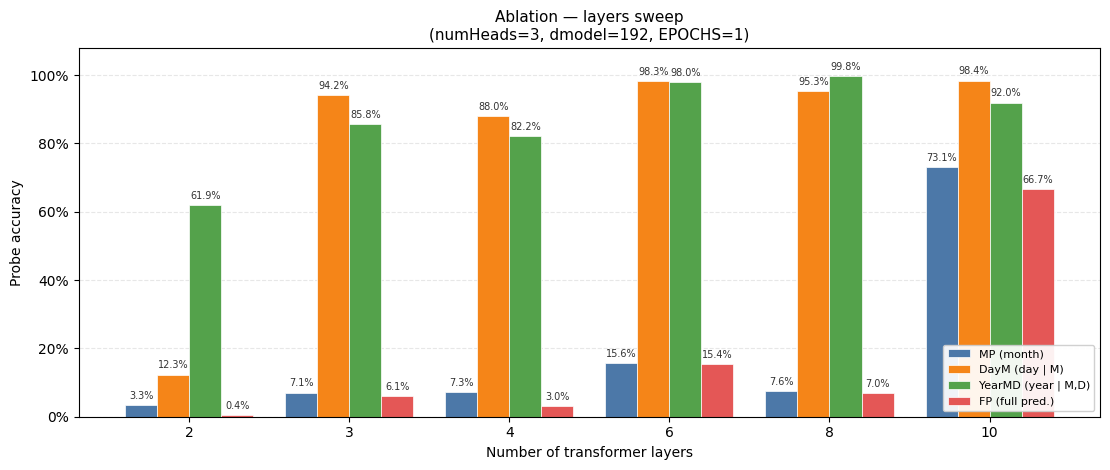

Saved → figure/layers.png


In [22]:
plot_study(
    study="layers",
    x_label="Number of transformer layers",
    fixed_config="numHeads=3, dmodel=192, EPOCHS=1",
)

In [23]:
show_and_save_table("layers")

Saved → figure/layers_table.csv
Saved → figure/layers_table.md


,MP,DayM,YearMD,FP
numLayers,,,,
2,3.3%,12.3%,61.9%,0.4%
3,7.1%,94.2%,85.8%,6.1%
4,7.3%,88.0%,82.2%,3.0%
6,15.6%,98.3%,98.0%,15.4%
8,7.6%,95.3%,99.8%,7.0%
10,73.1%,98.4%,92.0%,66.7%


## Epochs sweep

Holding `numLayers = 4`, `numHeads = 3`, `dmodel = 192`.

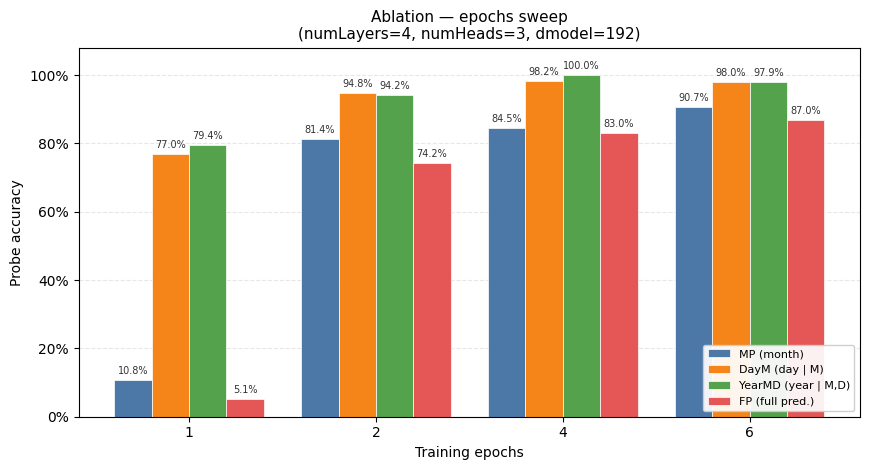

Saved → figure/epochs.png


In [24]:
plot_study(
    study="epochs",
    x_label="Training epochs",
    fixed_config="numLayers=4, numHeads=3, dmodel=192",
)

In [25]:
show_and_save_table("epochs")

Saved → figure/epochs_table.csv
Saved → figure/epochs_table.md


,MP,DayM,YearMD,FP
EPOCHS,,,,
1,10.8%,77.0%,79.4%,5.1%
2,81.4%,94.8%,94.2%,74.2%
4,84.5%,98.2%,100.0%,83.0%
6,90.7%,98.0%,97.9%,87.0%
